In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib
from matplotlib.gridspec import GridSpec
import matplotlib.patches
import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45, Heun
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger
from flax import serialization

# from schmitt_tdvp_blur_jaxmg import TDVPSchmittBlurJAXMg as DynamicsDriver
from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt

from tfim_exact_majorana import run_ed
import numpy as np

import os
import matplotlib.pyplot as plt

import sys

sys.path.append("../src")

import jax.numpy as jnp

import warnings
warnings.filterwarnings("error", category=jnp.ComplexWarning)

from gaussian_state import GaussianState

In [5]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)


def main(N, n_samples_tvmc, driver_type, q, alpha, load_parameter_path=None, t0=0.0, extra_str=""):
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

    def get_model():
        return nk.models.RBM(
            alpha=alpha,
            param_dtype=complex,
        )

    def get_vstate(n_samples):
        seed = 300
        model = get_model()
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
        )

        # zero everything
        pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

        W = pars["Dense"]["kernel"]
        a = pars["visible_bias"]
        b = pars["Dense"]["bias"]
        n = hilbert.size
        # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
        #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
        #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
        W = W.at[:, 0].set(-1j * (np.pi / 4))
        b = b.at[0].set(1j * (np.pi / 4) * n)
        # Repeat to get rid of sign since now
        # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
        #   -> even x: 1
        #   -> odd x: 0
        W = W.at[:, 1].set(-1j * (np.pi / 4))
        b = b.at[1].set(1j * (np.pi / 4) * n)
        # Unit 3 left as zero (neutral)
        pars["Dense"]["kernel"] = W
        pars["Dense"]["bias"] = (
            b + (1 + 1j) * jax.random.uniform(jax.random.key(100), b.shape) * 1e-4
        )
        pars["visible_bias"] = (
            jnp.zeros_like(pars["visible_bias"])
            + (1 + 1j) * jax.random.uniform(jax.random.key(100), a.shape) * N * 1e-4
        )

        # visible_bias stays zero
        vstate.parameters = pars
        return vstate

    # Check energy and parity
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx - sigma_z
    # Hamiltonian
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-1.0, J=1.0)

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    T = 2.0
    save_times = np.linspace(0.0, T, 40)
    if driver_type == "blur":
        exp_name = f"blur_{n_samples_tvmc}_{q:1.2f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/{extra_str}{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    vstate = get_vstate(n_samples_tvmc)
    if load_parameter_path is not None:
        with open(
            load_parameter_path,
            "rb",
        ) as infile:
            binary_data = infile.read()
            vstate.variables = serialization.from_bytes(vstate.variables, binary_data)
            vstate.variables = jax.tree.map(lambda x: jnp.array(x), vstate.variables)
        T = T - t0

    # Thermalize
    for i in range(1):
        vstate.sample()

    parity_expect = vstate.expect(sigma_z)
    stab_energy = vstate.expect(stab_hamiltonian)
    print(f"parity: {parity_expect}")
    print(f"parity: {stab_energy}")

    # Callbacks
    callbacks = []
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "bridge":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # Set up dynamics
    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}

    if driver_type == "blur":
        dynamics = TDVPSchmittBlur(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q=q,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [ ]:
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    main(8, 2**12, "bridge", q, alpha=4)

# load_path = (
#     f"./data/TFIM_{8}_parity/RBM_{4}/blur_{2**12}_{0.5:1.2f}/log_params_1.mpack"
# )
# main(8, 2**12, "vanilla", q, alpha=4, load_parameter_path=load_path, t0=0.05, extra_str="hotstart_")
main(8, 2**12, "vanilla", q, alpha=4)

Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
parity: 1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
parity: -8.999973+0.000019j ± 0.000086 [σ²=3.0e-05]


  2%|▏         | 0.04/2.03 [00:02<02:39, 79.5s/it, n=1, Generator=-0.048-0.000j ± 0.045 [σ²=8.2e+00]]


KeyboardInterrupt: 

In [ ]:

def main_gaussian(N, n_samples_tvmc, driver_type, q, h, T, dt_, chunk_size=None):
    print(N, n_samples_tvmc, driver_type, q, h, T)
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

    def get_model(dtype):
        return GaussianState(param_dtype=dtype)

    def get_vstates(n_samples, sampling_dtype=jnp.float64):
        seed = 300
        model = get_model(jnp.float64)
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
            chunk_size=chunk_size
        )
        model_sampling = get_model(sampling_dtype)
        sampler_sampling = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples, dtype=sampling_dtype
        )
        vstate_sampling = nk.vqs.MCState(
            sampler=sampler_sampling,
            model=model_sampling,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
        )

        return vstate, vstate_sampling

    vstate, _ = get_vstates(2**10)
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    Pz = nk.operator.PauliStringsJax(hilbert, "Z" * N, -1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx + Pz
    parity_expect = vstate.expect(sigma_z)
    stab_energy = vstate.expect(stab_hamiltonian)
    print(f"parity: {parity_expect}")
    print(f"parity: {stab_energy}")
    graph = nk.graph.Chain(N, pbc=True)
    # hamiltonian = sum([sigmax(hilbert, i) for i in graph.nodes()])
    # hamiltonian += sum([sigmaz(hilbert, i) @ sigmaz(hilbert, j) for i, j in graph.edges()])
    print(f"h={h:1.3f}")
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-h, J=1.0)

    print(vstate.expect(sigma_z))
    fields_to_track = (
        ("t", "values"),
        ("dt", "values"),
        ("Generator", "Mean"),
        ("Generator", "Variance"),
        ("parity", "Mean"),
        ("parity", "Variance"),
        ("r_squared", "values"),
        # Umbrella/bridge monitoring fields
        ("ess_bridge", "values"),
        ("snr_min", "values"),
        ("snr_10p", "values"),
        ("snr_med", "values"),
        ("snrF_min", "values"),
        ("snrF_med", "values"),
        ("q_bridge", "values"),
        # Per-step SNRs from OVar
        ("snr", "values"),
        ("snr_F", "values"),
        ("acceptance_rate", "values"),
    )

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    save_times = np.linspace(0.0, T, 40)
    if driver_type == "blur":
        exp_name = f"blur_{n_samples_tvmc}_h_{h:1.3f}_q_{q:1.3f}_T_{T:1.3f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}_h_{h:1.3f}_T_{T:1.3f}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_PFAFF_{N}_parity/{exp_name}/"
    print(save_path)
    logger = Logger(path=save_path, fields=fields_to_track, save_every=5)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        t0 = 0.0
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate, vstate_sampling = get_vstates(n_samples_tvmc, jnp.float32)

    # Thermalize
    for i in range(1):
        vstate.sample()
        vstate_sampling.sample()

    callbacks = []
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "blur":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    dt = dt_
    integrator = Heun(dt)
    tvmc_kwargs = {}

    if driver_type == "blur":
        dynamics = TDVPSchmittBlur(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q=q,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            sampling_state=vstate_sampling,
            distributed_eigh=True,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            distributed_eigh=True,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)


In [ ]:
main_gaussian(
    64,
    2 ** 13,
    'blur',
    q=0.5,
    h=0.125,
    T=2.0,
    dt_=0.004)

main_gaussian(
    64,
    2 ** 13,
    'blur',
    q=0.5,
    h=1.,
    T=0.5,
    dt_=0.001
)


64 8192 blur 0.5 0.125 2.0
parity: 0.9980+0.0000j ± 0.0020 [σ²=3.9e-03]
parity: -64.983-0.004j ± 0.012 [σ²=1.6e-01]
h=0.125
0.9980+0.0000j ± 0.0020 [σ²=3.9e-03]
./data/TFIM_PFAFF_64_parity/blur_8192_h_0.125_q_0.500_T_2.000/
Data exists, skipping...
64 8192 blur 0.5 1.0 0.5
parity: 0.9980+0.0000j ± 0.0020 [σ²=3.9e-03]
parity: -64.983-0.004j ± 0.012 [σ²=1.6e-01]
h=1.000
0.9980+0.0000j ± 0.0020 [σ²=3.9e-03]
./data/TFIM_PFAFF_64_parity/blur_8192_h_1.000_q_0.500_T_0.500/
Data exists, skipping...


Restored: True
Restored: True
Restored q:0.10 True
Restored q:0.30 True
Restored q:0.50 True
Restored q:0.70 True
Restored q:0.90 True


/tmp/ipykernel_3527838/2031900365.py:72: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(
/tmp/ipykernel_3527838/2031900365.py:116: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_inset.plot(times_exact, np.real(parity_exact), "k-", linewidth=1, linestyle="dashed")


Restored q:0.10 True
[array(nan), array(0.89844886), array(0.9021112), array(0.89600915), array(0.90308939), array(0.90162633), array(0.8972347), array(0.8962611), array(0.9052956), array(0.89553682), array(0.90408563), array(0.89799364), array(0.89410301), array(0.90461595), array(0.89830681), array(0.90080069), array(0.89965455), array(0.890201), array(0.89363679), array(0.89828887), array(0.90949118), array(0.89855571), array(0.90464655), array(0.89322625), array(0.89493758), array(0.90564614), array(0.9058976), array(0.89739543), array(0.89108435), array(0.90373651), array(0.89791376), array(0.89792504), array(0.90255472), array(0.90159446), array(0.89456), array(0.90647641), array(0.89992639), array(0.89799258), array(0.89605981), array(0.90141269), array(0.9014218), array(0.8982791), array(0.89416521), array(0.90170286), array(0.90098503), array(0.90754812), array(0.90076484), array(0.90150333), array(0.89812114), array(0.90493651), array(0.90252433), array(0.89647944), array(0.8

/tmp/ipykernel_3527838/2031900365.py:173: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_large_1.plot(
/tmp/ipykernel_3527838/2031900365.py:201: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_large_2.plot(


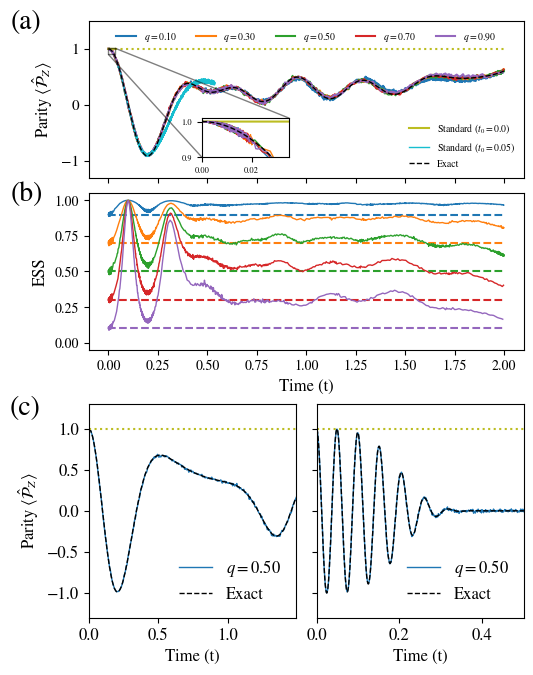

In [7]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
N = 8
alpha = 4
n_samples_to_plot = 2**12

label_fs = 12
tick_params = 12
legend = 15

times_exact, parity_exact = run_ed(N, h=1.0, J=1.0, T=2.0)
# Create figure with custom GridSpec for bottom row spacing
fig = plt.figure(figsize=(5.8, 7.75))
gs = GridSpec(2, 1, figure=fig, hspace=0.2, height_ratios=[2, 1.3])
gs_top = gs[0].subgridspec(2, 1, hspace=0.1)
gs_bot = gs[1].subgridspec(1, 2, wspace=0.1)
ax_z = fig.add_subplot(gs_top[0])
ax_ess = fig.add_subplot(gs_top[1], sharex=ax_z)
ax_large_1 = fig.add_subplot(gs_bot[0])
ax_large_2 = fig.add_subplot(gs_bot[1], sharey=ax_large_1)
fig.subplots_adjust(left=0.15)


# Vanilla Parity started from 0.05
save_path_vanilla = f"./data/TFIM_{N}_parity/RBM_{alpha}/vanilla_{n_samples_to_plot}/"
logger_vanilla = Logger(path=save_path_vanilla, fields=fields_to_track)
print("Restored:", logger_vanilla.restore())
color_t00 = "tab:olive"
color_t005 = "tab:cyan"
ax_z.plot(
    logger_vanilla.data["t"]["values"],
    np.array(logger_vanilla.data["parity"]["Mean"]).real,
    label=f"Standard ($t_0=0.0$)",
    zorder=1,
    color=color_t00,
)
# Vanilla Parity started from 0.05
save_path_vanilla_hotstart = (
    f"./data/TFIM_{N}_parity/RBM_{alpha}/hotstart_vanilla_{n_samples_to_plot}/"
)
logger_vanilla = Logger(path=save_path_vanilla_hotstart, fields=fields_to_track)
print("Restored:", logger_vanilla.restore())
ax_z.plot(
    logger_vanilla.data["t"]["values"][:7000],
    np.array(logger_vanilla.data["parity"]["Mean"][:7000]).real,
    label=r"Standard ($t_0=0.05$)",
    zorder=1,
    color=color_t005,
    lw=1,
)
ax_z.set_ylabel(r"Parity $\langle \hat{\mathcal{P}}_Z\rangle$", fontsize=label_fs)
plt.setp(ax_z.get_xticklabels(), visible=False)

# Bridge Parity
blur_lines = []
blur_labels = []
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    for n_samples in [n_samples_to_plot]:
        exp_name = f"blur_{n_samples}_{q:1.2f}"
        save_path = (
            f"./data/TFIM_{N}_parity/RBM_{alpha}/blur_{n_samples_to_plot}_{q:1.2f}/"
        )
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        (line,) = ax_z.plot(
            logger.data["t"]["values"],
            np.array(logger.data["parity"]["Mean"]).real,
            zorder=0,
        )
        blur_lines.append(line)
        blur_labels.append(f"$q = ${q:1.2f}")
ax_z.plot(
    times_exact,
    np.real(parity_exact),
    "k-",
    linewidth=1,
    label="Exact",
    zorder=1,
    linestyle="dashed",
)

# Inset zoomed in on early time
ax_inset = ax_z.inset_axes(
    [0.26, 0.13, 0.2, 0.25]
)  # [x, y, width, height] in axes coords
# Re-plot vanilla runs in inset
logger_vanilla_cold = Logger(path=save_path_vanilla, fields=fields_to_track)
logger_vanilla_cold.restore()
ax_inset.plot(
    logger_vanilla_cold.data["t"]["values"],
    np.array(logger_vanilla_cold.data["parity"]["Mean"]).real,
    color=color_t00,
)
cold_t = logger_vanilla_cold.data["t"]["values"][-1]   
cold_mag = logger_vanilla_cold.data["parity"]["Mean"][-1].real
ax_z.hlines(cold_mag, cold_t, 2.0, color="tab:olive", linestyle="dotted")

logger_vanilla_hot = Logger(path=save_path_vanilla_hotstart, fields=fields_to_track)
logger_vanilla_hot.restore()
ax_inset.plot(
    logger_vanilla_hot.data["t"]["values"][:7000],
    np.array(logger_vanilla_hot.data["parity"]["Mean"][:7000]).real,
    color=color_t005,
)
# Re-plot bridge runs in inset
for i, q_val in enumerate((0.1, 0.3, 0.5, 0.7, 0.9)):
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha}/blur_{n_samples_to_plot}_{q_val:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    lg.restore()
    ax_inset.plot(
        lg.data["t"]["values"],
        np.array(lg.data["parity"]["Mean"]).real,
        color=blur_lines[i].get_color(),
        lw=1,
    )
ax_inset.plot(times_exact, np.real(parity_exact), "k-", linewidth=1, linestyle="dashed")
ax_inset.set_xlim([0.0, cold_t])
ax_inset.set_ylim([0.9, 1.01])
ax_inset.tick_params(labelsize=6)
ax_z.indicate_inset_zoom(ax_inset, edgecolor="black")
# ESS
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    for n_samples in [n_samples_to_plot]:
        save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/blur_{n_samples}_{q:1.2f}/"
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        x_vals = logger.data["t"]["values"]
        ess_vals = logger.data["ess_bridge"]["values"]
        print(ess_vals)
        (line1,) = ax_ess.plot(x_vals, ess_vals, label=f"$q = ${q:1.2f}", lw=1)
        # Add marker at (0, q)
        ax_ess.hlines(1 - q, 0, 2.0, color=line1.get_color(), linestyle="dashed")

ax_ess.set_xlabel("Time (t)", fontsize=label_fs)
ax_ess.set_ylabel("ESS", fontsize=label_fs)
ax_ess.set_ylim(-0.05, 1.05)
# Two separate legends, both on the right
handles, labels = ax_z.get_legend_handles_labels()  # Plain x2 + Exact
# First legend: Plain + Exact, positioned to the left of the q legend
leg1 = ax_z.legend(
    handles,
    labels,
    loc="lower right",
    fontsize=7,
    frameon=False,
)
ax_z.add_artist(leg1)
# Second legend: bridge q-values horizontal at lower center
ax_z.legend(blur_lines, blur_labels, loc="upper center", fontsize=7, frameon=False, ncol=len(blur_labels))
ax_z.set_ylim([-1.3, 1.5])
ax_z.tick_params(labelsize=11)

N = 64
q = 0.5
n_samples_to_plot = 2**13

h = 1 / 8
T = 2.0
save_path = (
    f"./data/res_parity_pfaffian/blur_{n_samples_to_plot}_h_{h:1.3f}_q_{q:1.3f}_T_{T:1.3f}/"
)
print(save_path)
logger = Logger(path=save_path, fields=fields_to_track)
print(f"Restored q:{q:1.2f}", logger.restore())
times_exact, parity_exact = run_ed(N, h=h, J=1.0, T=T)
ax_large_1.plot(
    logger.data["t"]["values"],
    np.array(logger.data["parity"]["Mean"]).real,
    label=f"$q = ${q:1.2f}",
    zorder=0,
    lw=1,
)
ax_large_1.plot(
    times_exact,
    np.real(parity_exact),
    "k-",
    label="Exact",
    zorder=1,
    linestyle="dashed",
    lw=1,
)

N = 64
h = 1.0
T = 0.5
save_path = (
    f"./data/res_parity_pfaffian/blur_{n_samples_to_plot}_h_{h:1.3f}_q_{q:1.3f}_T_{T:1.3f}/"
)
print(save_path)
logger = Logger(path=save_path, fields=fields_to_track)
print(f"Restored q:{q:1.2f}", logger.restore())

times_exact, parity_exact = run_ed(N, h=h, J=1.0, T=T)
ax_large_2.plot(
    logger.data["t"]["values"],
    np.array(logger.data["parity"]["Mean"]).real,
    label=f"$q = ${q:1.2f}",
    zorder=0,
    lw=1,
)
ax_large_2.plot(
    times_exact[: len(times_exact) // 2],
    np.real(parity_exact)[: len(times_exact) // 2],
    "k-",
    label="Exact",
    zorder=1,
    linestyle="dashed",
    lw=1,
)
ax_large_1.hlines(1.0, 0, 1.5, linestyle='dotted', color=color_t00)
ax_large_2.hlines(1.0, 0, 0.5, linestyle='dotted', color=color_t00)

for i, ax in enumerate([ax_large_1, ax_large_2]):
    ax.set_xlabel("Time (t)", fontsize=label_fs)
    ax.legend(loc="lower right", fontsize=12, frameon=False)
    ax.tick_params(labelsize=tick_params)
    ax.set_ylim([-1.3, 1.3])
ax_large_1.set_ylabel(r"Parity $\langle \hat{\mathcal{P}}_Z\rangle$", fontsize=label_fs)
plt.setp(ax_large_2.get_yticklabels(), visible=False)
# ax_large_2.tick_params(axis='y', length=0)
ax_large_1.set_xlim([0,1.49])
ax_large_2.set_xlim([0,0.5])
loc_x = -0.18
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)
ax_ess.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)
loc_x = -0.38
loc_y = 0.95
ax_large_1.annotate("(c)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)
# ax_large_2.annotate("(d)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)

plt.savefig("Fig5.pdf", bbox_inches="tight", pad_inches=0.01)
